### 导入必要的库。

In [1]:
import matplotlib.pyplot as plt
import cv2
print("OpenCV 版本:", cv2.__version__)

OpenCV 版本: 4.11.0


### ORB 特征点检测和描述符计算。

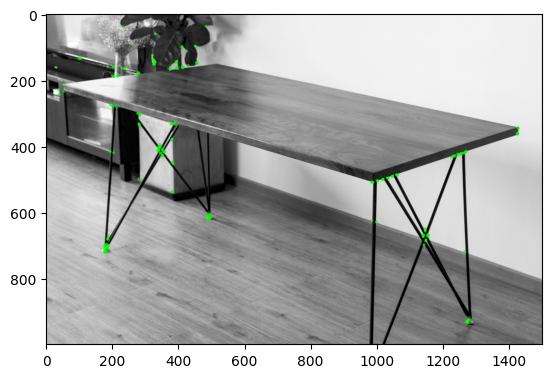

In [2]:
# 读取图片
img = cv2.imread('image.jpg', 0) 

if img is None:
    print("错误：找不到 image.jpg 图片，请检查文件名和路径！")
else:
    # 初始化 ORB 探测器
    orb = cv2.ORB_create()

    # 使用 ORB 寻找关键点
    kp = orb.detect(img, None)

    # 计算描述符
    kp, des = orb.compute(img, kp)

    # 绘制关键点
    img2 = cv2.drawKeypoints(img, kp, None, color=(0, 255, 0), flags=0)    # 这里第三个参数通常传 None，color 用 BGR 格式

    # 使用 matplotlib 显示
    plt.imshow(img2)
    plt.show()

我们发现绿点（关键点）非常有规律地出现在以下地方：

桌角的`顶点`： 典型的 L 型转角，像素在两个方向上都有剧烈变化。

桌腿的`交叉处`（X型支架）： 两条黑线的交汇点，这在算法眼里是极其“独特”的标志。

桌腿与地面的接触点： 颜色深浅变化的边界。

背景植物的叶尖： 复杂的形状和边缘。

下面我们将使用 ORB 来匹配两张图片中的特征点。我们有两张图片：`model.jpg` 和 `scene.jpg`

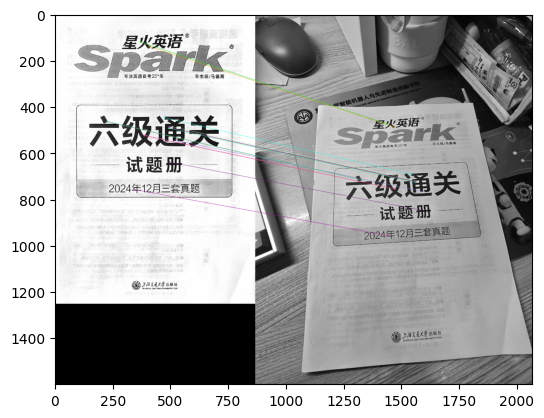

In [3]:
MIN_MATCHES = 15 # 最小匹配数，至少需要这么多匹配才能认为识别成功

# 读取场景图和模型图
cap = cv2.imread('scene.jpg', 0)    
model = cv2.imread('model.jpg', 0)

# ORB 特征点检测和描述符计算
orb = cv2.ORB_create()              

# 用于匹配的暴力匹配器，使用 Hamming 距离，并启用交叉检查
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)  

# 计算模型图的关键点和描述符
kp_model, des_model = orb.detectAndCompute(model, None)  

# 计算场景图的关键点和描述符
kp_frame, des_frame = orb.detectAndCompute(cap, None)

# 匹配描述符
matches = bf.match(des_model, des_frame)

# 分类匹配结果，按照距离排序，距离越小表示匹配越好
matches = sorted(matches, key=lambda x: x.distance)

# 检查匹配数量是否足够
if len(matches) > MIN_MATCHES:
    # draw first 15 matches.
    cap = cv2.drawMatches(model, kp_model, cap, kp_frame,
                          matches[:MIN_MATCHES], 0, flags=2)
    # 显示匹配结果
    plt.imshow(cap)
    plt.show()
else:
    print("Not enough matches have been found - %d/%d" % (len(matches), MIN_MATCHES))

这里的模型属于**平面**物体，不论我们怎么转动，它的变换都非常符合`单应性矩阵`。

而且它还具有**高对比度**和纹理，提供了大量`边缘`和`角点`。

以及**非重复性**：书面上的每个字、每个线条几乎都是唯一的。

这是最完美的 AR 追踪对象。

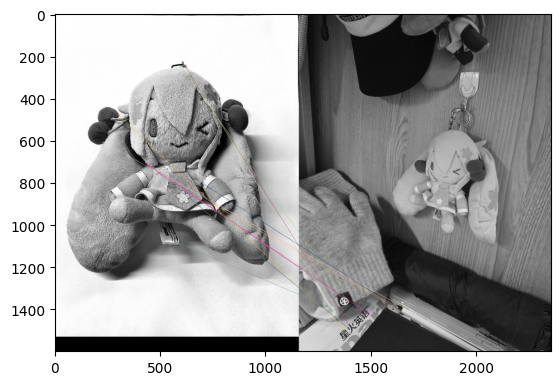

In [4]:
cap = cv2.imread('scene2.jpg', 0)    
model = cv2.imread('model2.jpg', 0)

orb = cv2.ORB_create()              
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)  
kp_model, des_model = orb.detectAndCompute(model, None)  
kp_frame, des_frame = orb.detectAndCompute(cap, None)
matches = bf.match(des_model, des_frame)
matches = sorted(matches, key=lambda x: x.distance)

if len(matches) > MIN_MATCHES:
    cap = cv2.drawMatches(model, kp_model, cap, kp_frame,
                          matches[:MIN_MATCHES], 0, flags=2)
    plt.imshow(cap)
    plt.show()
else:
    print("Not enough matches have been found - %d/%d" % (len(matches), MIN_MATCHES))

而对于第二个样本 (`3D 非平面物体`)，ORB的效果会比较差。

这里的玩偶是立体的，有弧度和厚度。我们在参考图中拍的是正面，但在场景图中，玩偶可能稍微侧了一点。由于它是立体的，侧一点点就会导致原本的特征点（比如眼睛、衣服褶皱）的形状发生**透视扭曲**，ORB等传统算法很难处理这种 3D 变化。

以及**纹理缺失**： 玩偶的头发、脸部是大面积的`平滑色块`。正如我们之前说的，算法讨厌平滑的地方，因为它找不到`角点`。

结果于是产生了大量**误匹配**（False Positives）。